# importing

In [ ]:
import pandas as pd
import numpy as np
import os
import sys
import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import IPython.display as ipd
from IPython.display import Audio

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Embedding, LSTM, BatchNormalization,GRU, Input, Flatten, Dropout, Activation, Conv1D, MaxPooling1D, AveragePooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 

print("Done - TensorFlow version:", tf.__version__)

Done - TensorFlow version: 2.20.0


organizng files into specific folder

In [ ]:
"""
import os
import shutil

def organize_crema_by_actor(source_dir, destination_dir):
    emotion_map = {
        'ANG': 'angry',
        'HAP': 'happy',
        'NEU': 'neutral',
        'SAD': 'sad'
    }
    
    if not os.path.exists(source_dir):
        print(f"Error: Source directory not found at {source_dir}")
        return

    if not os.path.exists(destination_dir):
        os.makedirs(destination_dir)
        
    files = os.listdir(source_dir)
    count = 0
    
    for file in files:
        if file.endswith('.wav'):
            parts = file.split('_')
            
            if len(parts) >= 3:
                actor_id = parts[0]
                emotion_code = parts[2]
                
                if emotion_code in emotion_map:
                    actor_folder = os.path.join(destination_dir, f"Actor_{actor_id}")
                    
                    if not os.path.exists(actor_folder):
                        os.makedirs(actor_folder)
                    
                    shutil.copy(os.path.join(source_dir, file), 
                                os.path.join(actor_folder, file))
                    count += 1
                            
    print(f"Success! Organized {count} files into actor-specific folders.")

source_path = r"C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\data\raw_audio\crema-D\AudioWAV"
dest_path = r"C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\data\raw_audio\crema-D\clean audio"

organize_crema_by_actor(source_path, dest_path)

Success! Organized 4900 files into actor-specific folders.


In [ ]:
"""
import os
import shutil

def organize_tess_final(source_dir, destination_dir):
   
    target_emotions = ['angry', 'happy', 'happiness', 'sad', 'neutral']
    
    if not os.path.exists(destination_dir):
        os.makedirs(destination_dir)

    folder_count = 0
    file_count = 0
    
    for folder_name in os.listdir(source_dir):
        folder_path = os.path.join(source_dir, folder_name)
        
        if os.path.isdir(folder_path):
         
            parts = folder_name.split('_')
            if len(parts) >= 2:
                actor_name = parts[0].upper() 
                emotion_in_folder = parts[1].lower()
                
                if emotion_in_folder in target_emotions:
                    actor_dest_folder = os.path.join(destination_dir, f"Actor_{actor_name}")
                    if not os.path.exists(actor_dest_folder):
                        os.makedirs(actor_dest_folder)
                    
                    for file_name in os.listdir(folder_path):
                        if file_name.endswith('.wav'):
                            shutil.copy(os.path.join(folder_path, file_name), 
                                        os.path.join(actor_dest_folder, file_name))
                            file_count += 1
                    folder_count += 1

    print(f"Success! Processed {folder_count} TESS folders and copied {file_count} files.")

source_tess = r"C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\data\raw_audio\tess\audioWAV"
dest_tess = r"C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\data\raw_audio\tess\clean audio"

organize_tess_final(source_tess, dest_tess)

Success! Processed 8 TESS folders and copied 1600 files.


In [ ]:
"""
import os
import shutil

def organize_savee_deep_scan(source_dir, destination_dir):
    if not os.path.exists(destination_dir):
        os.makedirs(destination_dir)

    file_count = 0
    
    for root, dirs, files in os.walk(source_dir):
        for file in files:
            if not file.endswith('.wav'):
                continue
            
            parts = file.split('_')
            if len(parts) < 2:
                continue
            
            actor_name = parts[0].upper()       
            emotion_code = parts[1][0].lower()  
            second_char = parts[1][1].lower() if len(parts[1]) > 1 else ""
            
            is_target = False
            if emotion_code in ['a', 'h', 'n']:
                is_target = True
            elif emotion_code == 's' and second_char != 'a':
                is_target = True
            
            if not is_target:
                continue
            
            dest_actor_folder = os.path.join(destination_dir, f"Actor_{actor_name}")
            if not os.path.exists(dest_actor_folder):
                os.makedirs(dest_actor_folder)
            
            shutil.copy(os.path.join(root, file),
                        os.path.join(dest_actor_folder, file))
            file_count += 1
                            
    print(f"SAVEE Success! Organized {file_count} files into actor folders.")


source_savee = r"C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\data\raw_audio\savee\SAVEE"
dest_savee = r"C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\data\raw_audio\savee\clean audio"

organize_savee_deep_scan(source_savee, dest_savee)

SAVEE Success! Organized 300 files into actor folders.


# Integration with Azure

In [6]:
!pip install azure-storage-blob

  Using cached azure_storage_blob-12.28.0-py3-none-any.whl.metadata (26 kB)
  Using cached azure_core-1.38.2-py3-none-any.whl.metadata (48 kB)
  Using cached isodate-0.7.2-py3-none-any.whl.metadata (11 kB)
Using cached azure_storage_blob-12.28.0-py3-none-any.whl (431 kB)
Using cached azure_core-1.38.2-py3-none-any.whl (217 kB)
Using cached isodate-0.7.2-py3-none-any.whl (22 kB)


In [ ]:
from azure.storage.blob import BlobServiceClient
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

connection_string = os.getenv("AZURE_STORAGE_CONNECTION_STRING")
container_name = "wav-files"

blob_service_client = BlobServiceClient.from_connection_string(connection_string)
container_client = blob_service_client.get_container_client(container_name)


def get_df_from_blob_dataset(prefix):
    emotions = []
    file_paths = []

    blobs = container_client.list_blobs(name_starts_with=prefix)

    for blob in blobs:
        if blob.name.endswith(".wav"):
            
            filename = blob.name.split("/")[-1]
            parts = filename.split('-')

            if len(parts) >= 3:
                emotion = parts[2].lower()
                emotions.append(emotion)
                file_paths.append(blob.name)

    return pd.DataFrame({
        'Emotions': emotions,
        'Path': file_paths
    })


ravdess_df = get_df_from_blob_dataset("RAVDESS/")
crema_df   = get_df_from_blob_dataset("CREMAD/")
tess_df    = get_df_from_blob_dataset("TESS/")
savee_df   = get_df_from_blob_dataset("SAVEE/")

data_path = pd.concat(
    [ravdess_df, crema_df, tess_df, savee_df],
    axis=0
)

data_path.reset_index(drop=True, inplace=True)

data_path.to_csv("data_path.csv", index=False)

print(data_path.head())
print("-" * 30)
print(data_path.Emotions.value_counts())

  Emotions                                          Path
0    angry  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup0.wav
1    angry  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup1.wav
2    angry  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup2.wav
3    angry  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup3.wav
4    angry  RAVDESS/Actor_01/RAVDESS-01-Angry-2-dup0.wav
------------------------------
Emotions
angry      1923
happy      1923
sad        1923
neutral    1703
Name: count, dtype: int64


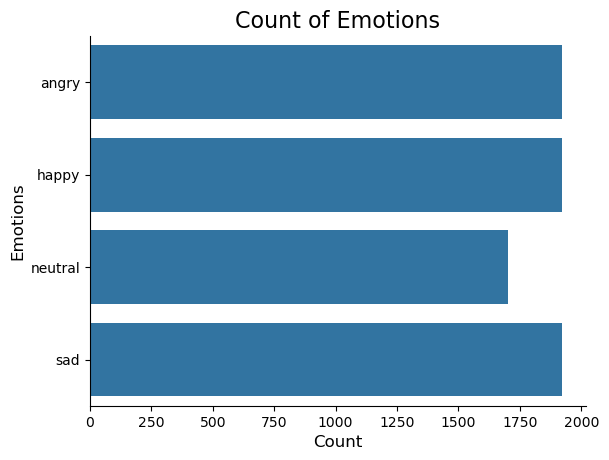

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.title('Count of Emotions', size=16)
sns.countplot(data_path.Emotions)
plt.ylabel('Emotions', size=12)
plt.xlabel('Count', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

# Data Augmentation

In [ ]:
import os
import pandas as pd
import numpy as np
import librosa
import warnings
import time
import io
from azure.storage.blob import BlobServiceClient

warnings.filterwarnings('ignore')

df = pd.read_csv("data_path.csv")

CONNECTION_STRING = os.getenv("AZURE_STORAGE_CONNECTION_STRING")
CONTAINER_NAME = "wav-files"

if not CONNECTION_STRING:
    raise ValueError("Connection String not found. Make sure you defined the AZURE_STORAGE_CONNECTION_STRING environment variable.")

blob_service_client = BlobServiceClient.from_connection_string(CONNECTION_STRING)

# Data Augmentation
def noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    return data + noise_amp * np.random.normal(size=data.shape[0])

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=pitch_factor)


# Feature Extraction of 30 features using MFCC algo
def extract_features(data, sr):
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=30)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    return mfcc_mean


def get_features(path):
    try:
        clean_path = path.replace('\\', '/')
        
        blob_client = blob_service_client.get_blob_client(container=CONTAINER_NAME, blob=clean_path)
        
        download_stream = blob_client.download_blob()
        audio_file = io.BytesIO(download_stream.readall())
        
        data, sr = librosa.load(audio_file, duration=2.5, offset=0.6)
        
        #extracting and augmanting each file 
        res1 = extract_features(data, sr)
        # Applying data augmentation
        res2 = extract_features(noise(data), sr)
        res3 = extract_features(stretch(data), sr)
        res4 = extract_features(shift(data), sr)
        res5 = extract_features(pitch(data, sr), sr)
        
        return [res1, res2, res3, res4, res5]
        
    except Exception as e:
        print(f"Error processing {path}: {e}")
        return None


X, Y = [], []  # X- list of vector for each file , y- real emotion of each file 

print(f"Starting to process {len(df)} files from Azure (Secure).")
start_time = time.time()

for index, row in df.iterrows():
    path = row['Path']
    emotion = row['Emotions']
    
    features = get_features(path)
    
    if features is not None:
        for ele in features:
            X.append(ele)
            Y.append(emotion)
            
    if (index + 1) % 100 == 0:
        print(f"Processed {index + 1}/{len(df)} files from the cloud...")

end_time = time.time()
print(f"Finished! Execution time: {round((end_time - start_time)/60, 2)} minutes.")


Features_df = pd.DataFrame(X)
Features_df['Labels'] = Y

Features_df.to_csv("features_ready_for_model.csv", index=False)
print(f"Data saved successfully. Total samples for training: {len(Features_df)}")

מתחיל לעבד 7472 קבצים מתוך Azure (מאובטח). התהליך ייקח זמן, קח קפה...
עובדו 100/7472 קבצים מהענן...
עובדו 200/7472 קבצים מהענן...
עובדו 300/7472 קבצים מהענן...
עובדו 400/7472 קבצים מהענן...
עובדו 500/7472 קבצים מהענן...
עובדו 600/7472 קבצים מהענן...
עובדו 700/7472 קבצים מהענן...
עובדו 800/7472 קבצים מהענן...
עובדו 900/7472 קבצים מהענן...
עובדו 1000/7472 קבצים מהענן...
עובדו 1100/7472 קבצים מהענן...
עובדו 1200/7472 קבצים מהענן...
עובדו 1300/7472 קבצים מהענן...
עובדו 1400/7472 קבצים מהענן...
עובדו 1500/7472 קבצים מהענן...
עובדו 1600/7472 קבצים מהענן...
עובדו 1700/7472 קבצים מהענן...
עובדו 1800/7472 קבצים מהענן...
עובדו 1900/7472 קבצים מהענן...
עובדו 2000/7472 קבצים מהענן...
עובדו 2100/7472 קבצים מהענן...
עובדו 2200/7472 קבצים מהענן...
עובדו 2300/7472 קבצים מהענן...
עובדו 2400/7472 קבצים מהענן...
עובדו 2500/7472 קבצים מהענן...
עובדו 2600/7472 קבצים מהענן...
עובדו 2700/7472 קבצים מהענן...
עובדו 2800/7472 קבצים מהענן...
עובדו 2900/7472 קבצים מהענן...
עובדו 3000/7472 קבצים מהענן...
עובדו 310

# Data Preperation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import pickle

Emotions = pd.read_csv('features_ready_for_model.csv')
# Handle missing values (NaN) by replacing them with 0
Emotions = Emotions.fillna(0)

#Separate Features (X) and Labels (Y)
X = Emotions.iloc[:, :-1].values
Y = Emotions['Labels'].values

print(f"Original data shapes - X: {X.shape}, Y: {Y.shape}")

# One-Hot Encoding for the labels (Y)
encoder = OneHotEncoder() #technice thay encodin emotion to vector of 0,1 - we dont encode emotions by 1,2,3 bcs the model may think 3 is bigger than 1 and we want treat all categories equally
Y = encoder.fit_transform(np.array(Y).reshape(-1, 1)).toarray() 

#Train/Test Split (80% training, 20% testing)
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=42, test_size=0.2, shuffle=True) # 20% of the data will be used for testing , shuffle - avoid overfitting
print(f"Train set: X={x_train.shape}, Y={y_train.shape}")
print(f"Test set: X={x_test.shape}, Y={y_test.shape}")

# Feature Scaling (Standardization)
print("Scaling features...")
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test) # Only transform for test set to avoid data leakage!

# Reshape data for 1D CNN (Adding a 3rd dimension)
print("Reshaping data for CNN...")
x_traincnn = np.expand_dims(x_train, axis=2)#axis =2 because we want to add a third dimension to the data (it's not stereo) - audio + mfcc vector
x_testcnn = np.expand_dims(x_test, axis=2)

print(f"Final shapes for CNN - Train: {x_traincnn.shape}, Test: {x_testcnn.shape}")

# Save Scaler and Encoder for future 
print("Saving scaler and encoder objects...")
with open('scaler.pickle', 'wb') as f:
    pickle.dump(scaler, f)
with open('encoder.pickle', 'wb') as f:
    pickle.dump(encoder, f)

print("Data is ready for the model.")

Original data shapes - X: (37360, 30), Y: (37360,)
Train set: X=(29888, 30), Y=(29888, 4)
Test set: X=(7472, 30), Y=(7472, 4)
Scaling features...
Reshaping data for CNN...
Final shapes for CNN - Train: (29888, 30, 1), Test: (7472, 30, 1)
Saving scaler and encoder objects...
Data is ready for the model.


# CNN Arcticeture

In [16]:
import tensorflow as tf
import tensorflow.keras.layers as L

print("Building the 1D CNN Architecture...")

model = tf.keras.Sequential([
    L.Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(x_traincnn.shape[1], 1)),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    
    L.Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    L.Dropout(0.2), 
    
    L.Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    
    L.Conv1D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    L.Dropout(0.2),  
    
    L.Conv1D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=3, strides=2, padding='same'),
    L.Dropout(0.2),  
    
    L.Flatten(),
    L.Dense(512, activation='relu'),
    L.BatchNormalization(),
    L.Dropout(0.2),
    
    L.Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Building the 1D CNN Architecture...


c:\Users\orbit_24ts2or\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 30, 512)        │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 30, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 15, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 15, 512)        │     1,311,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 15, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 8, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 8, 256)         │       655,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 4, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 4, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 2, 128)         │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 2, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             

 Total params: 2,342,020 (8.93 MB)

 Trainable params: 2,337,668 (8.92 MB)

 Non-trainable params: 4,352 (17.00 KB)

# Training Setup

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau



model_checkpoint = ModelCheckpoint('best_cnn_weights.h5', monitor='val_accuracy', save_best_only=True, verbose=1) #checkpoint- save the best model and delete the rest

#Early Stopping: Stops training if the model doesn't improve for 10 epochs
early_stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=10, restore_best_weights=True, verbose=1)

lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=5, verbose=1, factor=0.5, min_lr=0.00001) #if the model doesn't improve for 5 epochs, reduce the steps by 50% (gradient descent)

print("Callbacks are ready!")


Callbacks are ready!


# CNN Model

Epoch 1/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5143 - loss: 1.2183
Epoch 1: val_accuracy improved from None to 0.44526, saving model to best_cnn_weights.h5



Epoch 1: finished saving model to best_cnn_weights.h5
467/467 ━━━━━━━━━━━━━━━━━━━━ 45s 92ms/step - accuracy: 0.5735 - loss: 1.0265 - val_accuracy: 0.4453 - val_loss: 1.1838 - learning_rate: 0.0010
Epoch 2/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6500 - loss: 0.8032
Epoch 2: val_accuracy improved from 0.44526 to 0.67198, saving model to best_cnn_weights.h5



Epoch 2: finished saving model to best_cnn_weights.h5
467/467 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - accuracy: 0.6577 - loss: 0.7879 - val_accuracy: 0.6720 - val_loss: 0.7591 - learning_rate: 0.0010
Epoch 3/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6797 - loss: 0.7324
Epoch 3: val_accuracy improved from 0.67198 to 0.70476, saving model to best_cnn_weights.h5



Epoch 3: finished saving model to best_cnn_weights.h5
467/467 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.6793 - loss: 0.7348 - val_accuracy: 0.7048 - val_loss: 0.6716 - learning_rate: 0.0010
Epoch 4/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6956 - loss: 0.7046
Epoch 4: val_accuracy did not improve from 0.70476
467/467 ━━━━━━━━━━━━━━━━━━━━ 51s 110ms/step - accuracy: 0.6989 - loss: 0.7020 - val_accuracy: 0.6962 - val_loss: 0.6984 - learning_rate: 0.0010
Epoch 5/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7095 - loss: 0.6758
Epoch 5: val_accuracy improved from 0.70476 to 0.72497, saving model to best_cnn_weights.h5



Epoch 5: finished saving model to best_cnn_weights.h5
467/467 ━━━━━━━━━━━━━━━━━━━━ 79s 103ms/step - accuracy: 0.7106 - loss: 0.6754 - val_accuracy: 0.7250 - val_loss: 0.6538 - learning_rate: 0.0010
Epoch 6/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7233 - loss: 0.6494
Epoch 6: val_accuracy did not improve from 0.72497
467/467 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - accuracy: 0.7223 - loss: 0.6518 - val_accuracy: 0.7033 - val_loss: 0.6919 - learning_rate: 0.0010
Epoch 7/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7328 - loss: 0.6234
Epoch 7: val_accuracy did not improve from 0.72497
467/467 ━━━━━━━━━━━━━━━━━━━━ 51s 108ms/step - accuracy: 0.7314 - loss: 0.6309 - val_accuracy: 0.7244 - val_loss: 0.6461 - learning_rate: 0.0010
Epoch 8/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7538 - loss: 0.5938
Epoch 8: val_accuracy improved from 0.72497 to 0.75254, saving model to best_cnn_weights.h5


...


Epoch 32: finished saving model to best_cnn_weights.h5
467/467 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - accuracy: 0.9482 - loss: 0.1384 - val_accuracy: 0.8909 - val_loss: 0.3745 - learning_rate: 0.0010
Epoch 33/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9549 - loss: 0.1204
Epoch 33: val_accuracy did not improve from 0.89093
467/467 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.9524 - loss: 0.1289 - val_accuracy: 0.8866 - val_loss: 0.3867 - learning_rate: 0.0010
Epoch 34/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9553 - loss: 0.1243
Epoch 34: val_accuracy did not improve from 0.89093
467/467 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9515 - loss: 0.1308 - val_accuracy: 0.8866 - val_loss: 0.3822 - learning_rate: 0.0010
Epoch 35/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9602 - loss: 0.1069
Epoch 35: val_accuracy improved from 0.89093 to 0.89226, saving model to best_cnn_weights.h5



Epoch 35: finished saving model to best_cnn_weights.h5
467/467 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - accuracy: 0.9571 - loss: 0.1169 - val_accuracy: 0.8923 - val_loss: 0.3678 - learning_rate: 0.0010
Epoch 36/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9593 - loss: 0.1112
Epoch 36: val_accuracy did not improve from 0.89226
467/467 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9584 - loss: 0.1149 - val_accuracy: 0.8921 - val_loss: 0.3584 - learning_rate: 0.0010
Epoch 37/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9589 - loss: 0.1133
Epoch 37: val_accuracy did not improve from 0.89226
467/467 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9596 - loss: 0.1138 - val_accuracy: 0.8880 - val_loss: 0.3781 - learning_rate: 0.0010
Epoch 38/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9636 - loss: 0.0989
Epoch 38: val_accuracy improved from 0.89226 to 0.90190, saving model to best_cnn_weights.h5



Epoch 38: finished saving model to best_cnn_weights.h5
467/467 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9617 - loss: 0.1045 - val_accuracy: 0.9019 - val_loss: 0.3350 - learning_rate: 0.0010
Epoch 39/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9663 - loss: 0.0971
Epoch 39: val_accuracy did not improve from 0.90190
467/467 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9624 - loss: 0.1064 - val_accuracy: 0.8908 - val_loss: 0.3749 - learning_rate: 0.0010
Epoch 40/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9656 - loss: 0.0938
Epoch 40: val_accuracy did not improve from 0.90190
467/467 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9644 - loss: 0.0977 - val_accuracy: 0.8917 - val_loss: 0.3709 - learning_rate: 0.0010
Epoch 41/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9667 - loss: 0.0911
Epoch 41: val_accuracy did not improve from 0.90190
467/467 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - accuracy: 0.9656 - loss: 0.0949 - val_accuracy


Epoch 44: finished saving model to best_cnn_weights.h5
467/467 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - accuracy: 0.9796 - loss: 0.0585 - val_accuracy: 0.9085 - val_loss: 0.3625 - learning_rate: 5.0000e-04
Epoch 45/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9828 - loss: 0.0467
Epoch 45: val_accuracy did not improve from 0.90846
467/467 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - accuracy: 0.9833 - loss: 0.0468 - val_accuracy: 0.9074 - val_loss: 0.3930 - learning_rate: 5.0000e-04
Epoch 46/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9851 - loss: 0.0412
Epoch 46: val_accuracy did not improve from 0.90846
467/467 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9848 - loss: 0.0430 - val_accuracy: 0.9052 - val_loss: 0.4080 - learning_rate: 5.0000e-04
Epoch 47/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9874 - loss: 0.0360
Epoch 47: val_accuracy did not improve from 0.90846
467/467 ━━━━━━━━━━━━━━━━━━━━ 54s 115ms/step - accuracy: 0.9863 - loss: 0.0400 -


Epoch 50: finished saving model to best_cnn_weights.h5
467/467 ━━━━━━━━━━━━━━━━━━━━ 51s 110ms/step - accuracy: 0.9907 - loss: 0.0274 - val_accuracy: 0.9123 - val_loss: 0.4039 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 50.
 Model has finished training.
Plotting training history...


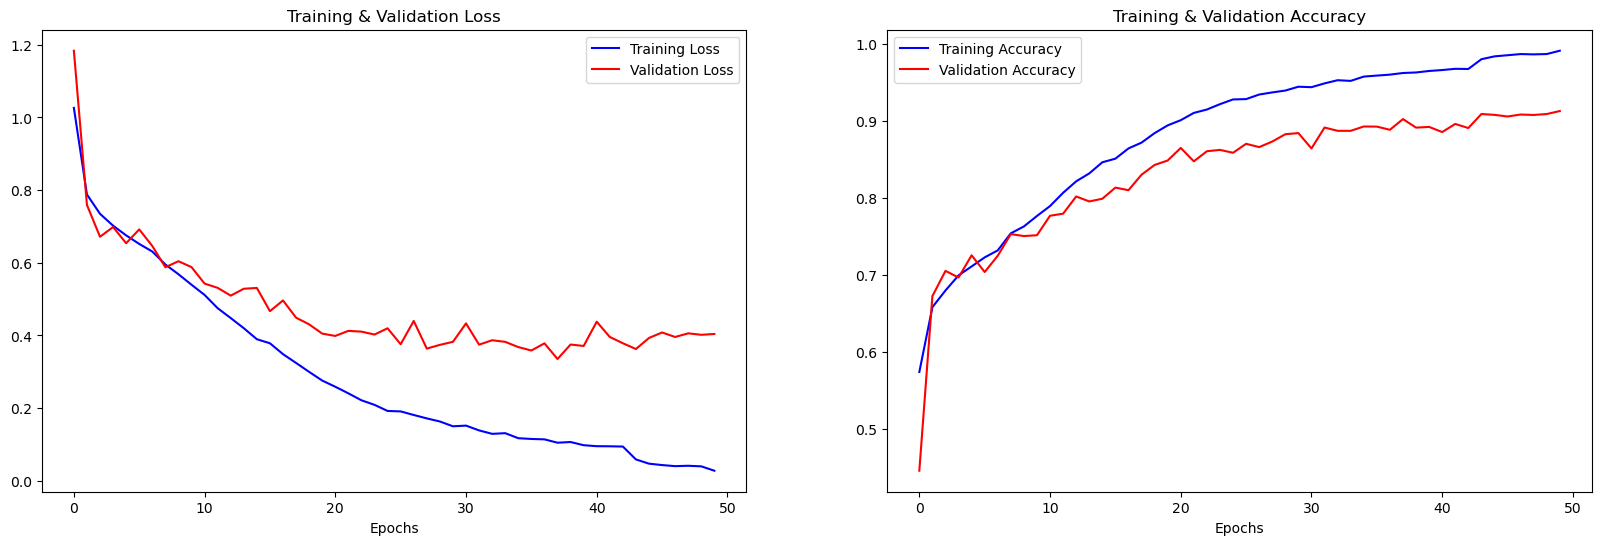

In [18]:
import matplotlib.pyplot as plt


# --- The actual training step ---
history = model.fit(
    x_traincnn, y_train, 
    epochs=50, #epoch - one pass through the entire dataset (~30K samples) 
    validation_data=(x_testcnn, y_test), 
    batch_size=64, #take 64 samples each time
    callbacks=[early_stop, lr_reduction, model_checkpoint]
)

print(" Model has finished training.")


print("Plotting training history...")
epochs = range(len(history.history['accuracy']))
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# Plotting Loss
ax[0].plot(epochs, history.history['loss'], label='Training Loss', color='blue')
ax[0].plot(epochs, history.history['val_loss'], label='Validation Loss', color='red')
ax[0].set_title('Training & Validation Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

# Plotting Accuracy
ax[1].plot(epochs, history.history['accuracy'], label='Training Accuracy', color='blue')
ax[1].plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax[1].set_title('Training & Validation Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")

plt.show()

In [19]:
# predicting on test data.
pred_test0 = model.predict(x_testcnn)
y_pred0 = encoder.inverse_transform(pred_test0)
y_test0 = encoder.inverse_transform(y_test)

# Check for random predictions
df0 = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df0['Predicted Labels'] = y_pred0.flatten()
df0['Actual Labels'] = y_test0.flatten()

df0.head(10)

234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


,Predicted Labels,Actual Labels
0,angry,angry
1,neutral,neutral
2,angry,angry
3,neutral,neutral
4,angry,angry
5,angry,angry
6,angry,angry
7,sad,sad
8,happy,happy
9,happy,neutral


# Evaluation

234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


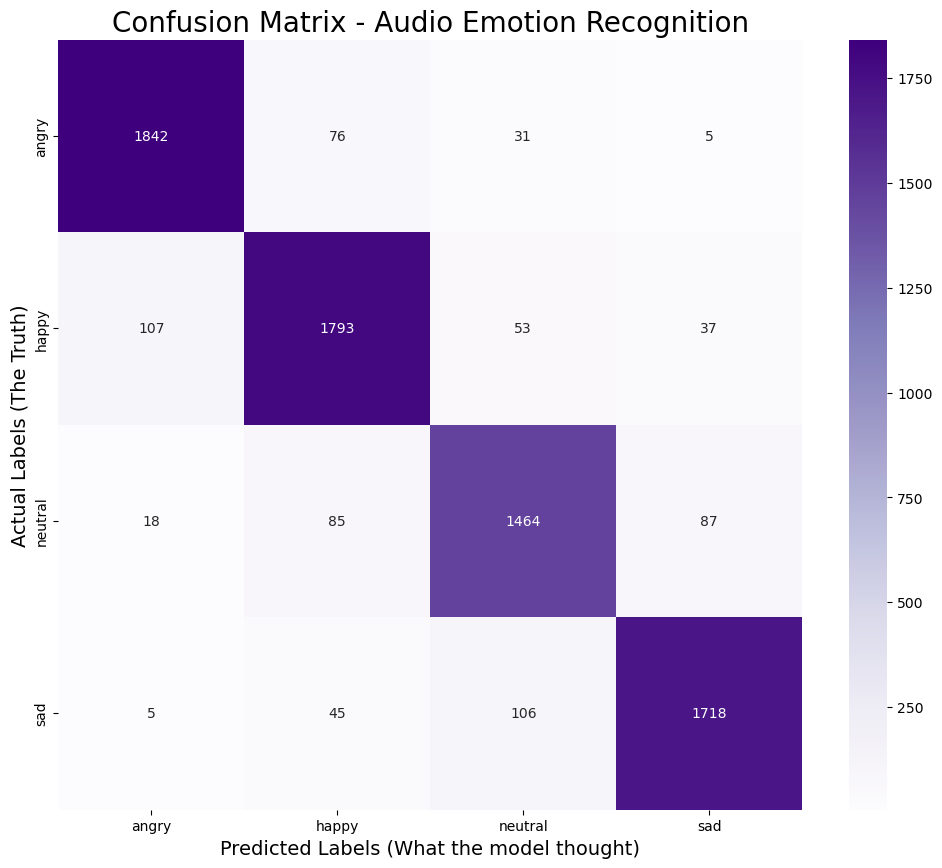


--- Detailed Classification Report ---
              precision    recall  f1-score   support

       angry       0.93      0.94      0.94      1954
       happy       0.90      0.90      0.90      1990
     neutral       0.89      0.89      0.89      1654
         sad       0.93      0.92      0.92      1874

    accuracy                           0.91      7472
   macro avg       0.91      0.91      0.91      7472
weighted avg       0.91      0.91      0.91      7472



In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


pred_test = model.predict(x_testcnn)

y_pred_labels = encoder.inverse_transform(pred_test)
y_test_labels = encoder.inverse_transform(y_test)

cm = confusion_matrix(y_test_labels, y_pred_labels)

labels = encoder.categories_[0]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix - Audio Emotion Recognition', size=20)
plt.xlabel('Predicted Labels (What the model thought)', size=14)
plt.ylabel('Actual Labels (The Truth)', size=14)
plt.show()

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test_labels, y_pred_labels))

# Saving the model

In [ ]:
import numpy as np
import librosa
import pickle
from tensorflow.keras.models import load_model


# Save the final model (Keras format)
model.save('final_emotion_model.keras')
print("Model saved as: final_emotion_model.keras")

#Function to extract features from a single new audio file
def extract_features_single(path):
    # Load audio exactly like we did during training
    data, sr = librosa.load(path, duration=2.5, offset=0.6)
    
    # Extract MFCC
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=30)
    result = np.mean(mfcc.T, axis=0) # Mean across time
    
    return result

# 3. The master Prediction Function
def predict_emotion(audio_path):
    # Step A: Extract features
    feat = extract_features_single(audio_path)
    
    # Step B: Scale features using the scaler we saved earlier
    feat = scaler.transform(feat.reshape(1, -1))
    
    # Step C: Reshape for CNN (Add the 3rd dimension)
    feat = np.expand_dims(feat, axis=2)
    
    # Step D: Predict probabilities
    predictions = model.predict(feat, verbose=0)
    
    # Step E: Get the emotion label and confidence
    emotion = encoder.inverse_transform(predictions)
    confidence = np.max(predictions)
    
    return emotion[0][0], confidence

print("System is ready for new predictions!")

✅ Model saved as: final_emotion_model.keras
System is ready for new predictions!
